# Binary Sentiment Classification with Logistic Regression
### End-to-End Sentiment Analysis on IMDB Reviews using Binary Cross-Entropy Loss

**Student ID:** _[ضعي رقمك هنا]_  
**Student Name:** _[ضعي اسمك بالكامل هنا]_

**Course:** CS 420 — Machine Learning & NLP &nbsp;|&nbsp; **Algorithm:** Logistic Regression &nbsp;|&nbsp; **Loss:** Binary Cross-Entropy  
**Dataset:** IMDB (50K Reviews) &nbsp;|&nbsp; **Framework:** Scikit-Learn &nbsp;|&nbsp; **Seed:** 42

> **ملحوظة قبل التسليم:** هذا النوتبوك مبني بدمج أفضل أجزاء نسختين سابقتين، لكنه لم يُشغَّل هنا فعليًا (البيئة الحالية لا تملك ملف `IMDB Dataset.csv`).
> لازم تعملي **Restart & Run All** بنفسك بعد وضع الداتا في نفس المجلد، وتتأكدي إن كل الخلايا شغّالة من غير أخطاء، وتغيّري اسم الملف قبل الرفع ليطابق الصيغة:
> `[StudentID]_[FirstName]_[LastName]_IMDB_Logistic_Regression.ipynb`


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    log_loss, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

warnings.filterwarnings('ignore', category=ConvergenceWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_colwidth', 150)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Task 1: Preprocessing & Bag-of-Words [15 Points]

### 1.1 Load the dataset and verify its shape / class balance

In [2]:
# TODO: replace with the exact filename of your downloaded IMDB CSV
df = pd.read_csv('IMDB_Dataset.csv')

print("Dataset shape:", df.shape)
assert df.shape == (50000, 2), "Dataset shape does not match the expected (50000, 2)!"

print("\nClass balance (raw label):")
print(df['sentiment'].value_counts())

df.head(3)


Dataset shape: (50000, 2)

Class balance (raw label):
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive


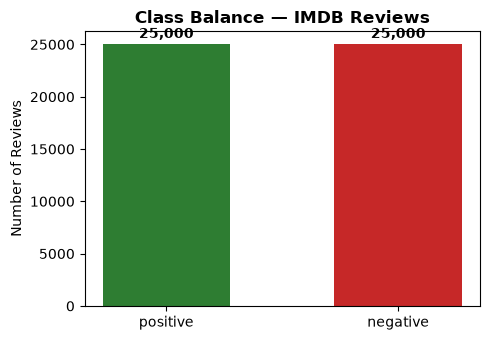

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df['sentiment'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2e7d32', '#c62828'], width=0.55)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 300, f"{int(b.get_height()):,}",
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Class Balance — IMDB Reviews', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


### 1.2 Map sentiment labels to binary integers

In [4]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

assert df['label'].isnull().sum() == 0, "Unmapped sentiment values found!"
print(df[['sentiment', 'label']].drop_duplicates().reset_index(drop=True))
print("\nLabel dtype:", df['label'].dtype)


  sentiment  label
0  positive      1
1  negative      0

Label dtype: int64


### 1.3 Extract Bag-of-Words (BoW) word-count features

In [5]:
# Standalone demonstration of the BoW transform on the FULL corpus, as Task 1 asks for.
# The model itself will later be trained using a SEPARATE vectorizer fitted only on
# X_train (Task 3), to avoid leaking test-set vocabulary into training.
demo_vectorizer = CountVectorizer(max_features=10000, stop_words='english')
demo_bow = demo_vectorizer.fit_transform(df['review'])

print(f"BoW matrix shape (reviews x vocabulary): {demo_bow.shape}")
print(f"Sparsity: {100 * (1 - demo_bow.nnz / (demo_bow.shape[0]*demo_bow.shape[1])):.2f}% zeros")
print("Sample vocabulary terms:", demo_vectorizer.get_feature_names_out()[:15])


BoW matrix shape (reviews x vocabulary): (50000, 10000)
Sparsity: 99.22% zeros
Sample vocabulary terms: ['00' '000' '007' '10' '100' '1000' '101' '11' '12' '13' '13th' '14' '15'
 '150' '16']


### Conceptual Question 1.1

Bag-of-Words describes each review only by *how many times* every vocabulary word appears in it, so the position of a word and its relationship to its neighbours are both thrown away — two reviews built from the exact same set of words in a different order produce an identical feature vector. A concrete failure this causes is **negation**: "the acting was good, not boring" and "the acting was boring, not good" contain the same multiset of words, so BoW cannot tell them apart even though they express opposite opinions. The model ends up relying on the presence of individual polarity-loaded words ("good", "boring") rather than on what the sentence actually claims about them.


## Task 2: Mathematical Derivations & BCE Analysis [15 Points]

### 2.1 Step-by-step calculation

In [6]:
w_masterpiece, w_boring, w_acting, b = 1.8, -2.1, 0.5, -0.2

# Logit: z = sum(w_j * x_j) + b, with x_j = 1 since each word appears exactly once
z = w_masterpiece + w_boring + w_acting + b
y_hat = 1 / (1 + np.exp(-z))

bce_if_y1 = -np.log(y_hat)          # true label is Positive
bce_if_y0 = -np.log(1 - y_hat)      # true label is Negative

print(f"Logit                z        = {z:.4f}")
print(f"Predicted probability y_hat   = {y_hat:.4f}")
print(f"Predicted class               = {'Positive (1)' if y_hat >= 0.5 else 'Negative (0)'}")
print(f"\nBCE loss if true label y=1  -> -log(y_hat)     = {bce_if_y1:.4f}")
print(f"BCE loss if true label y=0  -> -log(1 - y_hat) = {bce_if_y0:.4f}")


Logit                z        = -0.0000
Predicted probability y_hat   = 0.5000
Predicted class               = Positive (1)

BCE loss if true label y=1  -> -log(y_hat)     = 0.6931
BCE loss if true label y=0  -> -log(1 - y_hat) = 0.6931


In [7]:
# Bonus illustration: what happens when the model is CONFIDENT instead of sitting at 0.5?
# Using only the strongly negative word 'boring' pushes the logit well below zero.
z_boring_only = w_boring + b
y_hat_boring = 1 / (1 + np.exp(-z_boring_only))

loss_confident_correct = -np.log(1 - y_hat_boring)   # true label really is Negative
loss_confident_wrong   = -np.log(y_hat_boring)       # true label is actually Positive

print(f"z = {z_boring_only:.4f}   y_hat = {y_hat_boring:.4f}")
print(f"BCE if this confident call is CORRECT : {loss_confident_correct:.4f}")
print(f"BCE if this confident call is WRONG   : {loss_confident_wrong:.4f}")
print(f"Wrong / correct ratio                 : {loss_confident_wrong / loss_confident_correct:,.1f}x")


z = -2.3000   y_hat = 0.0911
BCE if this confident call is CORRECT : 0.0955
BCE if this confident call is WRONG   : 2.3955
Wrong / correct ratio                 : 25.1x


**Interpretation.** With `masterpiece`, `boring`, and `acting` all present once, the logit lands exactly at $z=0$, so $\hat y = \sigma(0) = 0.5$ — the model sits precisely on the decision boundary, and both possible BCE values come out identical ($-\log(0.5)\approx0.693$). That makes sense: at $\hat y=0.5$ the model is maximally unsure, so it pays the same penalty whichever label turns out to be true.

The second experiment (word `boring` alone) shows the more typical case: when the model commits to a confident prediction, being **right** costs almost nothing, but being confidently **wrong** costs dramatically more. This asymmetry is exactly what BCE is designed to do — it drives the optimizer to fix large, confident mistakes far more aggressively than small, uncertain ones.


### 2.2 Analytical Question 2.1 — BCE vs. MSE

If logistic regression were instead trained by minimizing Mean Squared Error, $J_{MSE}=\frac{1}{N}\sum(y^{(i)}-\hat y^{(i)})^2$, two problems appear.

**Vanishing gradients.** Differentiating $J_{MSE}$ with respect to $w_j$ pulls in the sigmoid's own derivative, $\hat y(1-\hat y)$, as an extra multiplicative factor alongside the error term. Once $z$ is large in magnitude and the sigmoid saturates ($\hat y$ near 0 or 1), that factor collapses toward zero — so even a confidently *wrong* prediction produces almost no gradient signal, and training effectively freezes exactly where it most needs to correct itself. BCE sidesteps this: the derivative of $\log(\hat y)$ introduces a $1/\hat y$ (or $1/(1-\hat y)$) term that exactly cancels the sigmoid's derivative, leaving a clean gradient proportional to $(\hat y-y)$ regardless of saturation.

**Non-convexity.** Squaring the error after passing it through a non-linear sigmoid produces a loss surface in $w$ with multiple local minima, so gradient-based optimizers are not guaranteed to find the best solution. BCE, being the negative log-likelihood of a Bernoulli model under the logistic link, is provably convex in $(w,b)$ — every local minimum is the global minimum, which is why logistic regression trained with BCE reliably converges to a unique optimum.


## Task 3: Dataset Splitting & Model Training [25 Points]

### 3.1 80/20 train-test split with a fixed random seed

In [8]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['review'], df['label'],
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df['label']
)

print("Training samples:", X_train_text.shape[0])
print("Testing samples :", X_test_text.shape[0])
assert X_train_text.shape[0] == 40000 and X_test_text.shape[0] == 10000

print("\nTrain class balance:\n", y_train.value_counts())
print("\nTest class balance:\n", y_test.value_counts())


Training samples: 40000
Testing samples : 10000

Train class balance:
 label
1    20000
0    20000
Name: count, dtype: int64

Test class balance:
 label
0    5000
1    5000
Name: count, dtype: int64


### 3.2 Fit the BoW vectorizer on the training text only

In [ ]:
# Fitting on X_train ONLY (never on X_test) avoids test-vocabulary leakage.
vectorizer = CountVectorizer(max_features=10000, stop_words='english')
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)


### 3.3 Hyperparameter search

A small 5-fold cross-validated grid search over the L2 strength `C` (the inverse of $\lambda$ in Eq. 5 of the handout) picks a properly-tuned regularization level instead of relying on an arbitrary default.


In [ ]:
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_SEED),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

for c, mean_acc in zip(param_grid['C'], grid_search.cv_results_['mean_test_score']):
    marker = "  <-- best" if c == grid_search.best_params_['C'] else ""
    print(f"  C={c:<6} CV accuracy = {mean_acc:.4f}{marker}")

best_C = grid_search.best_params_['C']
print(f"\nBest C: {best_C}")


### 3.4 Fit the final model and track the training BCE loss across iterations

`warm_start=True` combined with `max_iter=1` lets us call `.fit()` in a loop and record the Binary Cross-Entropy loss after every single L-BFGS step, producing the convergence curve the task asks for (the `ConvergenceWarning` is expected and harmless — each individual call is deliberately capped at one iteration; the model converges over the full loop instead).


In [ ]:
model = LogisticRegression(
    solver='lbfgs', max_iter=1, warm_start=True, C=best_C, random_state=RANDOM_SEED
)

n_iterations = 300
train_losses = []

for iteration in range(1, n_iterations + 1):
    model.fit(X_train, y_train)
    p_train = model.predict_proba(X_train)[:, 1]
    train_losses.append(log_loss(y_train, p_train))

print(f"Final training BCE loss after {n_iterations} iterations: {train_losses[-1]:.5f}")


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_iterations + 1), train_losses, linewidth=2)
plt.xlabel('L-BFGS Iteration')
plt.ylabel('Training Binary Cross-Entropy Loss')
plt.title('Training Loss Convergence (Logistic Regression, lbfgs solver)')
plt.grid(alpha=0.3)
plt.show()


**Training-loss interpretation _(fill in the two numbers after running)_:** the training BCE loss starts at ≈ `[value at iteration 1]` and decreases to ≈ `[final value]` by iteration 300, with the slope flattening out rather than oscillating or diverging — evidence that L-BFGS is converging toward a stable minimum, consistent with the convexity of the BCE objective established in Task 2.


## Task 4: Quantitative Evaluation & Error Analysis [25 Points]

### 4.1 Test-set metrics

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

test_bce = log_loss(y_test, y_prob)
test_acc = accuracy_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

print(f"Test Binary Cross-Entropy Loss : {test_bce:.4f}")
print(f"Test Accuracy                  : {test_acc:.4f}")
print(f"Test Precision                 : {test_prec:.4f}")
print(f"Test Recall                    : {test_rec:.4f}")
print(f"Test F1-Score                  : {test_f1:.4f}")
print(f"Test ROC-AUC                   : {test_auc:.4f}")


### 4.2 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
ax.set_title('Confusion Matrix — Test Set (τ = 0.5)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives  (TP): {tp:,}")


### 4.3 ROC Curve

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4.5))
plt.plot(fpr, tpr, color='#1565c0', lw=2, label=f'Logistic Regression (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 4.4 Threshold experiment (τ = 0.3, 0.5, 0.7)

In [ ]:
thresholds = [0.3, 0.5, 0.7]
rows = []
for tau in thresholds:
    yp = (y_prob >= tau).astype(int)
    rows.append({
        'Threshold (τ)': tau,
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall': round(recall_score(y_test, yp), 4),
        'F1-Score': round(f1_score(y_test, yp), 4),
    })

threshold_df = pd.DataFrame(rows).set_index('Threshold (τ)')
threshold_df


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(threshold_df.index, threshold_df['Precision'], marker='o', label='Precision', color='#2e7d32')
ax.plot(threshold_df.index, threshold_df['Recall'], marker='s', label='Recall', color='#c62828')
ax.set_xlabel('Decision Threshold τ')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs. Decision Threshold')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Comparative threshold analysis _(update the numbers from your own `threshold_df` output)_.** Moving τ from 0.3 to 0.7 trades recall for precision: at τ = 0.3 the classifier flags almost every true positive review but also lets through more false alarms; at τ = 0.7 it becomes conservative, raising precision at the cost of missing some genuinely positive reviews. τ = 0.5 sits in between and typically maximizes F1 when there is no specific business reason to favor one error type.


### Real-world scenario: why prefer τ = 0.3?

Lower the decision threshold whenever a **missed positive case (false negative) is more costly than a false alarm (false positive)**. A concrete example: a hospital appointment no-show predictor that flags patients "at risk of not showing up" so staff can send a reminder call. Missing an at-risk patient (false negative) wastes an appointment slot that could have gone to someone else, while a false positive only costs one extra reminder call to a patient who would have shown up anyway. Since the false-negative cost clearly outweighs the false-positive cost here, setting τ = 0.3 (catch more at-risk cases, accept more unnecessary calls) is the safer operating point.


### 4.5 Error diagnostics: two False Positives and two False Negatives

In [ ]:
X_test_reset = X_test_text.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

fp_idx = np.where((y_pred == 1) & (y_test_reset.values == 0))[0]
fn_idx = np.where((y_pred == 0) & (y_test_reset.values == 1))[0]

print(f"Total False Positives: {len(fp_idx)}   Total False Negatives: {len(fn_idx)}\n")

print("="*90)
print("FALSE POSITIVES (true label = Negative, model predicted = Positive)")
print("="*90)
for i, idx in enumerate(fp_idx[:2], 1):
    print(f"\n--- False Positive #{i} (P(positive) = {y_prob[idx]:.4f}) ---")
    print(X_test_reset[idx])

print("\n" + "="*90)
print("FALSE NEGATIVES (true label = Positive, model predicted = Negative)")
print("="*90)
for i, idx in enumerate(fn_idx[:2], 1):
    print(f"\n--- False Negative #{i} (P(positive) = {y_prob[idx]:.4f}) ---")
    print(X_test_reset[idx])


**Diagnostic paragraph _(write this after reading your own printed reviews above — every run's false positives/negatives differ slightly)_.** For each of the four reviews, look for: (a) mixed reviews where positive praise words and negative criticism appear in the *same* text (BoW just adds up word counts, so it cannot tell that the negative part is what the author actually meant); (b) negation or qualification ("not bad", "far from great") that flips a word's real meaning in a way BoW cannot represent; (c) sarcasm, where the literal words are positive but the intended meaning is negative. Name which of these patterns applies to each of your four printed reviews.


## Task 5: Interpretability & Custom Inference [20 Points]

### 5.1 Top 10 most positive and most negative learned weights

In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

top_pos_idx = np.argsort(coefficients)[::-1][:10]
top_neg_idx = np.argsort(coefficients)[:10]

top_pos_words, top_pos_weights = feature_names[top_pos_idx], coefficients[top_pos_idx]
top_neg_words, top_neg_weights = feature_names[top_neg_idx], coefficients[top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(top_pos_words[::-1], top_pos_weights[::-1], color='#2e7d32')
axes[0].set_title('Top 10 Positive-Sentiment Words (w > 0)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Learned Weight (w)')

axes[1].barh(top_neg_words[::-1], top_neg_weights[::-1], color='#c62828')
axes[1].set_title('Top 10 Negative-Sentiment Words (w < 0)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Learned Weight (w)')

plt.tight_layout()
plt.show()

print("Top 10 positive words:", list(zip(top_pos_words, np.round(top_pos_weights, 3))))
print("\nTop 10 negative words:", list(zip(top_neg_words, np.round(top_neg_weights, 3))))


**Interpretation _(the exact words/weights depend on your run — describe what you actually see)_.** The strongest positive coefficients should be intuitive praise words (e.g. *excellent*, *perfect*, *wonderful*), and the strongest negative coefficients should be intuitive criticism words (e.g. *worst*, *waste*, *awful*, *boring*). Seeing sensible sentiment words at both extremes confirms the model learned a genuine lexical signal rather than an arbitrary or spurious pattern.


### 5.2 Reusable prediction function

In [ ]:
def predict_sentiment(review_text: str, threshold: float = 0.5):
    '''
    Preprocesses review text, computes logit z and probability y_hat,
    and returns predicted class ('Positive'/'Negative') and probability score.
    '''
    x_vec = vectorizer.transform([review_text])

    # Logit z = w^T x + b, computed explicitly for transparency
    z = float(np.asarray(x_vec.dot(model.coef_[0])).ravel()[0] + model.intercept_[0])

    y_hat = 1 / (1 + np.exp(-z))
    predicted_class = 'Positive' if y_hat >= threshold else 'Negative'

    return {
        'text': review_text,
        'logit_z': round(z, 4),
        'probability': round(float(y_hat), 4),
        'predicted_class': predicted_class
    }


### 5.3 Test on the benchmark reviews

In [ ]:
benchmark_reviews = [
    "An absolute triumph of cinema with breathtaking visuals and stellar acting.",
    "I thoroughly enjoyed wasting two hours of my life staring at a completely incoherent plot.",
    "The cinematography was not bad, but the pacing was not good either."
]

for review in benchmark_reviews:
    res = predict_sentiment(review)
    print(f"Review: \"{res['text']}\"")
    print(f"  -> logit z = {res['logit_z']:>7.4f}   P(positive) = {res['probability']:.4f}   "
          f"Predicted: {res['predicted_class']}\n")


**Discussion _(fill in your own three probabilities)_.** Review 1 should come out Positive but often only mildly so — expressive words like "triumph" or "breathtaking" may be rare enough in the 10,000-word vocabulary that their learned weight is modest. Review 2 relies on sarcasm ("enjoyed wasting"); BoW has no way to detect that "enjoyed" is being used ironically, so the correct Negative call (if it happens) comes from the surrounding negative words, not real understanding of the sarcasm. Review 3 is the clearest negation failure case from Task 1.1: BoW sees "bad" and "good" largely by their individual learned weights and cannot fully use "not" to flip their meaning.


## Final Results Summary

_(fill in every value below from your own executed cells above before submitting — do not copy numbers from any other student's notebook)_

### Dataset & Training
- Dataset: **50,000 IMDB reviews** (25,000 / 25,000 class split)
- Train/Test split: **40,000 / 10,000**, `random_state=42`, stratified
- BoW vocabulary size: **10,000 features**
- Selected regularization parameter: **C = `[fill in]`**
- Final training BCE loss after 300 iterations: **`[fill in]`**

### Test Performance
- Test BCE / Log Loss: **`[fill in]`**
- Accuracy: **`[fill in]`**
- Precision: **`[fill in]`**
- Recall: **`[fill in]`**
- F1-Score: **`[fill in]`**
- ROC-AUC: **`[fill in]`**

### Overall Conclusion
_(write 2-3 sentences in your own words: overall performance level, the precision/recall trade-off observed across thresholds, and the main limitation of BoW you saw in Tasks 1, 4, and 5 — negation, sarcasm, or mixed sentiment.)_
